In [66]:
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter, NullFormatter, ScalarFormatter
import numpy as np
import pandas as pd
import seaborn as sb
import seaborn.objects as so
import math


df = pd.read_csv("results/scaling.csv", skip_blank_lines=True)
df["cells"] = [int(x.rsplit("/", 2)[1])**3 for x in df["case_long"]]
df["ms_normed"] = df["time_mean_ms"] / df["cells"]
strategies = list(df["strategy"].unique())
cpu = df[df["executor"] == "cpu"]
cpu["Threads"] = [int(x.split("-")[1])if x.split("-")[1] != "serial" else 1 for x in cpu["variant"] ]
cpu["cellsPerCpu"] = cpu["cells"]/cpu["Threads"]
cpu["logth"] = [int(math.log2(x)) for x in cpu["Threads"]]
group_cols = [
    "case_long",
    "strategy",
    "language",
    "precision",
    "executor",
    "use_kernelAbstractions",
    "use_fusing",
]

baseline = (
    cpu[cpu["variant"].str.contains("serial")]
    .groupby(group_cols, as_index=False)["time_mean_ms"]
    .first()
    .rename(columns={"time_mean_ms": "serial_time"})
)

cpu = cpu.merge(baseline, on=group_cols, how="left")
cpu["speedup"] = cpu["serial_time"] / cpu["time_mean_ms"]
cpu["efficiency"] = cpu["speedup"] / cpu["Threads"]

sb.set_theme()
cpu["logthp1"] = cpu["logth"] + 1


In [16]:
cpu

,time_mean_ms,time_median_ms,gc_time_mean_ms,gc_time_median_ms,case_short,case_long,strategy,variant,language,precision,...,use_kernelAbstractions,use_fusing,cells,ms_normed,Threads,cellsPerCpu,logth,serial_time,speedup,efficiency
0,9.788398,9.778989,0.0,0.0,cases/Lid-Driven-Cavities/100/,cases/Lid-Driven-Cavities/100/,faceBased,SOAFusedFaceBasedAssembly-serial,julia,float64,...,False,True,1000000,0.000010,1,1000000.0,0,9.788398,1.000000,1.000000
1,14.669528,14.605256,0.0,0.0,cases/Lid-Driven-Cavities/100/,cases/Lid-Driven-Cavities/100/,globalFaceBased,FusedGlobalFaceBased-serial,julia,float64,...,False,True,1000000,0.000015,1,1000000.0,0,14.669528,1.000000,1.000000
2,39.010220,38.944776,0.0,0.0,cases/Lid-Driven-Cavities/100/,cases/Lid-Driven-Cavities/100/,batchedFace,FusedBatchedFaceBased-serial,julia,float64,...,False,True,1000000,0.000039,1,1000000.0,0,39.010220,1.000000,1.000000
3,41.356421,41.303329,0.0,0.0,cases/Lid-Driven-Cavities/100/,cases/Lid-Driven-Cavities/100/,cellBased,FusedCellBased-serial,julia,float64,...,False,True,1000000,0.000041,1,1000000.0,0,41.356421,1.000000,1.000000
4,18.451786,18.412309,0.0,0.0,cases/Lid-Driven-Cavities/100/,cases/Lid-Driven-Cavities/100/,faceBased,SOAFusedFaceBasedAssemblyThreaded-2,julia,float64,...,False,True,1000000,0.000018,2,500000.0,1,9.788398,0.530485,0.265243
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,8.577562,8.132132,0.0,0.0,cases/Lid-Driven-Cavities/80/,cases/Lid-Driven-Cavities/80/,cellBased,FusedCellBased-128,julia,float64,...,False,True,512000,0.000017,128,4000.0,7,21.851823,2.547556,0.019903
356,11.039399,10.073415,0.0,0.0,cases/Lid-Driven-Cavities/80/,cases/Lid-Driven-Cavities/80/,faceBased,SOAFusedFaceBasedAssemblyThreaded-256,julia,float64,...,False,True,512000,0.000022,256,2000.0,8,5.079225,0.460100,0.001797
357,10.483474,9.409002,0.0,0.0,cases/Lid-Driven-Cavities/80/,cases/Lid-Driven-Cavities/80/,globalFaceBased,FusedGlobalFaceBased-256,julia,float64,...,False,True,512000,0.000020,256,2000.0,8,7.472391,0.712778,0.002784
358,52.906521,52.120709,0.0,0.0,cases/Lid-Driven-Cavities/80/,cases/Lid-Driven-Cavities/80/,batchedFace,FusedBatchedFaceBased-256,julia,float64,...,False,True,512000,0.000103,256,2000.0,8,20.146596,0.380796,0.001487


In [121]:
strategies

['faceBased', 'globalFaceBased', 'batchedFace', 'cellBased']

In [ ]:
sorted(cpu["cells"].unique())

[np.int64(8000),
 np.int64(64000),
 np.int64(216000),
 np.int64(512000),
 np.int64(1000000),
 np.int64(1728000),
 np.int64(2744000),
 np.int64(4096000),
 np.int64(5832000),
 np.int64(8000000)]

In [20]:
cpc = cpu.groupby(["strategy"])["cellsPerCpu"].unique()
for c in cpc:
    print(f"{c}")


[1.000000e+06 5.000000e+05 2.500000e+05 1.250000e+05 6.250000e+04
 3.125000e+04 1.562500e+04 7.812500e+03 3.906250e+03 1.728000e+06
 8.640000e+05 4.320000e+05 2.160000e+05 1.080000e+05 5.400000e+04
 2.700000e+04 1.350000e+04 6.750000e+03 2.744000e+06 1.372000e+06
 6.860000e+05 3.430000e+05 1.715000e+05 8.575000e+04 4.287500e+04
 2.143750e+04 1.071875e+04 4.096000e+06 2.048000e+06 1.024000e+06
 5.120000e+05 2.560000e+05 1.280000e+05 6.400000e+04 3.200000e+04
 1.600000e+04 5.832000e+06 2.916000e+06 1.458000e+06 7.290000e+05
 3.645000e+05 1.822500e+05 9.112500e+04 4.556250e+04 2.278125e+04
 8.000000e+03 4.000000e+03 2.000000e+03 1.000000e+03 5.000000e+02
 2.500000e+02 1.250000e+02 6.250000e+01 3.125000e+01 8.000000e+06
 4.000000e+06 2.000000e+06 3.375000e+03 1.687500e+03 8.437500e+02]
[1.000000e+06 5.000000e+05 2.500000e+05 1.250000e+05 6.250000e+04
 3.125000e+04 1.562500e+04 7.812500e+03 3.906250e+03 1.728000e+06
 8.640000e+05 4.320000e+05 2.160000e+05 1.080000e+05 5.400000e+04
 2.700000

In [123]:
def scaleplot(strategy_df, ax):
    # compute speedup
    plot = sb.lineplot(data=strategy_df, x="Threads", y=yvar, ax=ax)
    plot.set_title(strategy)
    return plot

In [124]:
def pareff(strategy_df, ax):
    # compute speedup
    plot = sb.lineplot(data=strategy_df, x="Threads", y="efficiency", ax=ax)
    plot.set_title(strategy)
    return plot

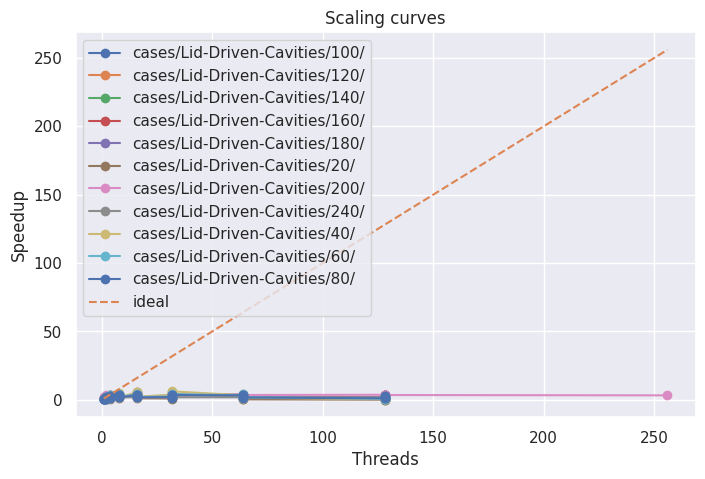

In [126]:
fig, ax = plt.subplots(figsize=(8, 5))

for case, sub in df.groupby("case_long"):
    sub = sub.sort_values("Threads")
    ax.plot(sub["Threads"], sub[yvar], marker="o", label=case)

# ideal scaling line
xmax = df["Threads"].max()
ax.plot([1, xmax], [1, xmax], linestyle="--", label="ideal")

ax.set_xlabel("Threads")
ax.set_ylabel("Speedup")
ax.set_title("Scaling curves")
ax.legend()
ax.grid(True)

plt.show()

In [127]:
table = df.pivot_table(
    index="Threads",
    columns="case_long",
    values="speedup"
)
table

case_long,cases/Lid-Driven-Cavities/100/,cases/Lid-Driven-Cavities/120/,cases/Lid-Driven-Cavities/140/,cases/Lid-Driven-Cavities/160/,cases/Lid-Driven-Cavities/180/,cases/Lid-Driven-Cavities/20/,cases/Lid-Driven-Cavities/200/,cases/Lid-Driven-Cavities/240/,cases/Lid-Driven-Cavities/40/,cases/Lid-Driven-Cavities/60/,cases/Lid-Driven-Cavities/80/
Threads,,,,,,,,,,,
1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.464957,1.000000,1.000000,1.000000,1.000000
2,1.537126,1.556567,1.557873,1.553865,1.554568,1.541115,1.921660,1.040488,1.568869,1.624471,1.547788
4,2.346758,2.381367,2.309642,2.294945,2.329281,2.583043,2.532625,1.669234,2.615935,2.552025,2.393447
8,2.694727,2.707920,2.671632,2.717229,2.746993,2.830391,2.941194,1.863404,3.471454,3.153593,2.831194
16,2.686729,2.752639,2.744316,2.761252,2.796857,3.264992,2.969270,1.904882,4.082946,3.170926,2.715307
32,2.661128,2.744540,2.766206,2.773292,2.813265,3.061056,2.965868,1.890709,4.040562,3.056806,2.697696
64,2.586287,2.720196,2.742292,2.749526,2.800744,1.282688,2.964017,1.881616,2.502412,2.700269,2.603086
128,2.214101,2.539441,2.697953,2.726908,2.774024,0.432561,2.948334,1.857868,1.118284,1.478388,1.853645
256,NaN,NaN,NaN,NaN,NaN,NaN,3.310504,NaN,NaN,NaN,NaN


In [128]:
fig, axes = plt.subplots(5, 2)

for k, v in table.items():
    
for case, sub in df.groupby("case_long"):
    sub = sub.sort_values("nthreads")
    ax.plot(sub["nthreads"], sub["speedup"], marker="o", label=case)

xmax = df["nthreads"].max()
ax.plot([1, xmax], [1, xmax], linestyle="--", label="ideal")

ax.set_xlabel("Threads")
ax.set_ylabel("Speedup")
ax.set_title("Scaling curves")
ax.legend()
ax.grid(True)


plt.tight_layout()

IndentationError: expected an indented block after 'for' statement on line 3 (1892177537.py, line 5)

TypeError: Data source must be a DataFrame or Mapping, not <class 'str'>.

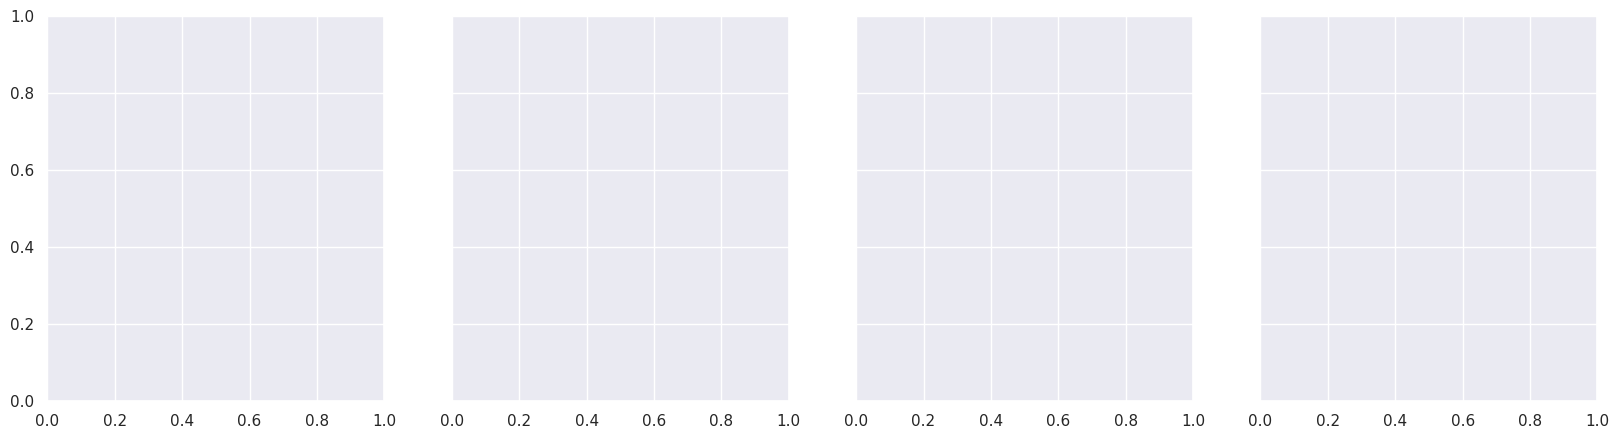

In [129]:
fig, axes = plt.subplots(1,4, figsize=(20, 5), sharey=True)

for i, strat in enumerate(strategies):
    scaleplot(strat, axes.flat[i])

/tmp/ipykernel_56539/2953831244.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(df["Threads"].unique())
/tmp/ipykernel_56539/2953831244.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(df["Threads"].unique())
/tmp/ipykernel_56539/2953831244.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(df["Threads"].unique())
/tmp/ipykernel_56539/2953831244.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(df["Threads"].unique())


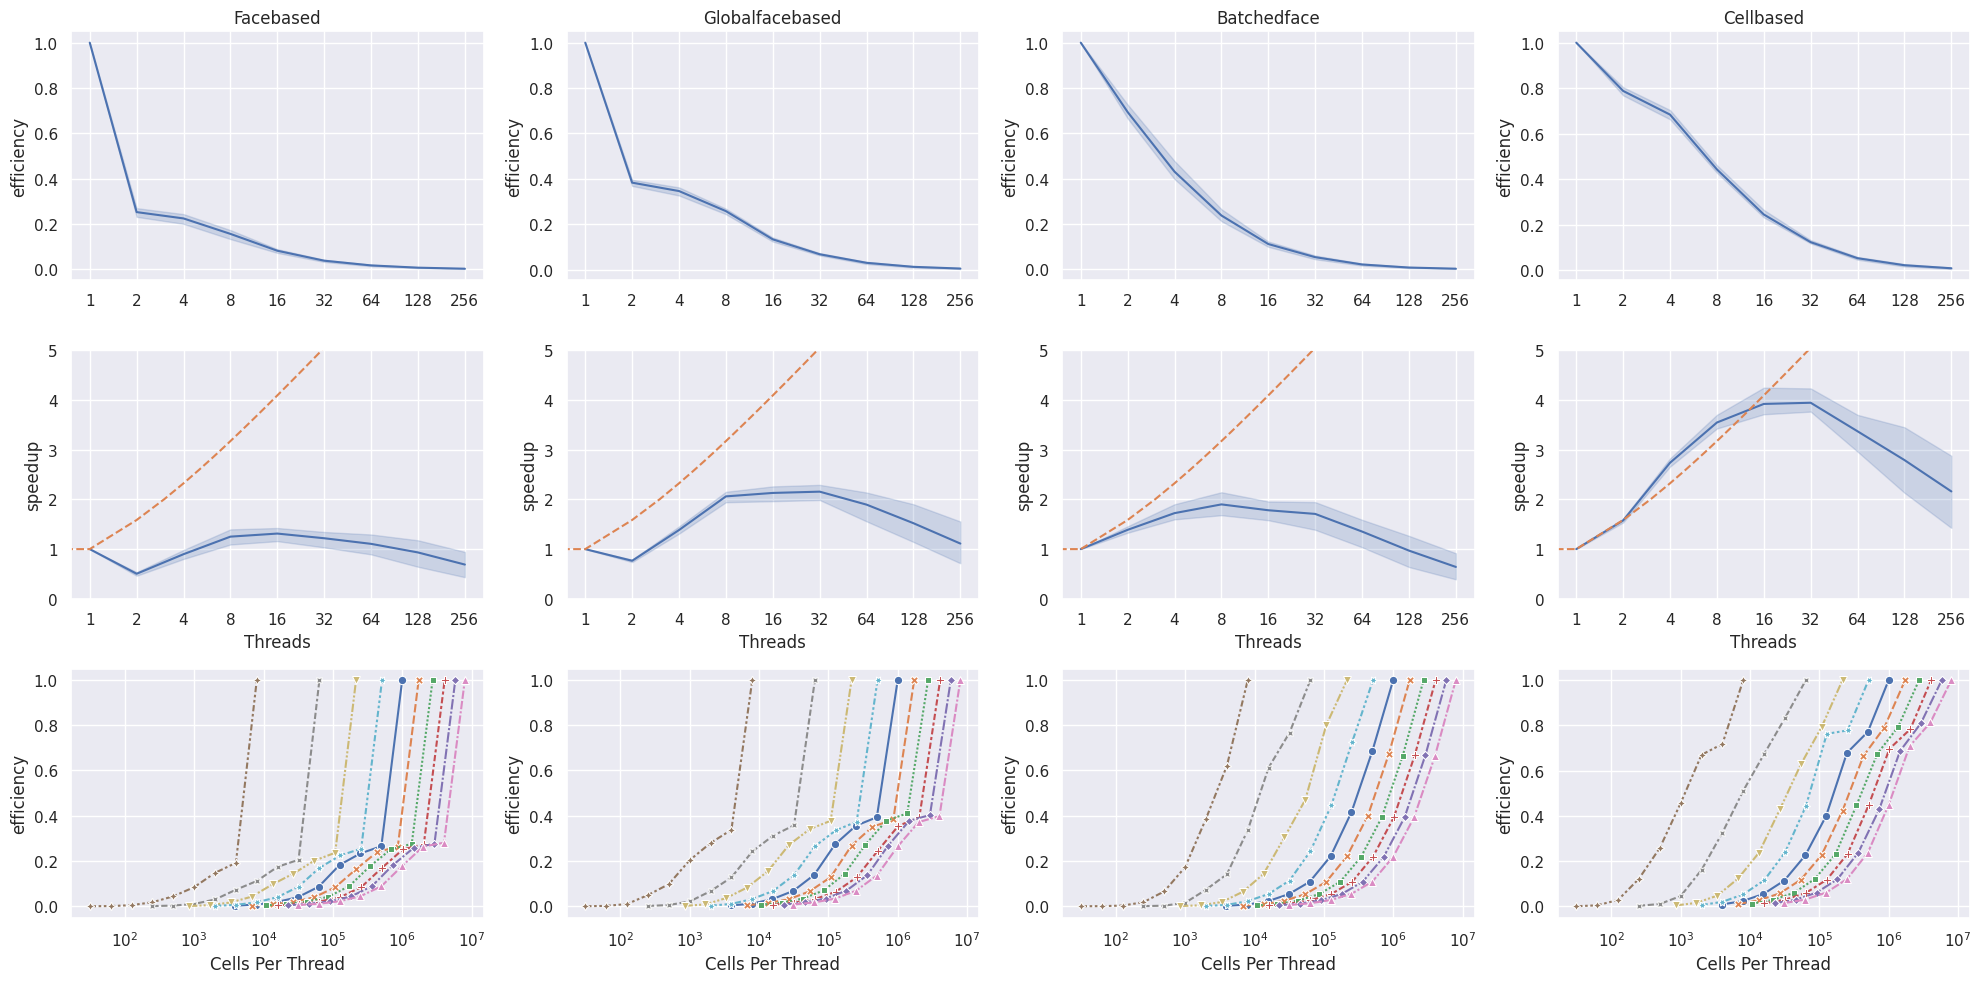

In [2]:
fig, axes = plt.subplots(3,4, figsize=(20, 10), sharey=False, sharex=False)

for i, strat in enumerate(strategies):
    plot = sb.lineplot(data=df[df["strategy"] == strat], x="logth", y="efficiency", ax=axes.flat[i])
    plot.set_title(strat.capitalize())
    plot.set_xticklabels(df["Threads"].unique())
    plot.set(
        xlabel=""
    )
    plot.set_xticks(df["logth"].unique())
    plot = sb.lineplot(data=df[df["strategy"] == strat], x="Threads", y="speedup", ax=axes.flat[i+4])
    axes.flat[i+4].plot([math.log2(x) for x in range(1,128)], linestyle="--", label="ideal")
    # plot.set(xscale="log")
    axes.flat[i+4].set_xscale('log', base=2)
    plot.set_ylim([0, 5])


    plot.set_xticks(df["Threads"].unique())
    plot.set_xticklabels(df["Threads"].unique())
    plot.set(
        xlabel="Threads"
    )
    plot = sb.lineplot(data=df[df["strategy"] == strat], x="cellsPerCpu", y="efficiency", ax=axes.flat[i+8], legend=False, markers=True, style="case_long", hue="case_long")
    plot.set(
        xlabel="Cells Per Thread"
    )
    plot.set(xscale="log")
    # plot.set_xticklabels(df["Threads"].unique())
    # plot.set_xticks(df["logth"].unique())
    # axes.flat[i+8].ticklabel_format(useOffset=False, style='plain')

plt.tight_layout()
plt.savefig("figures/cpu_scaling.svg")

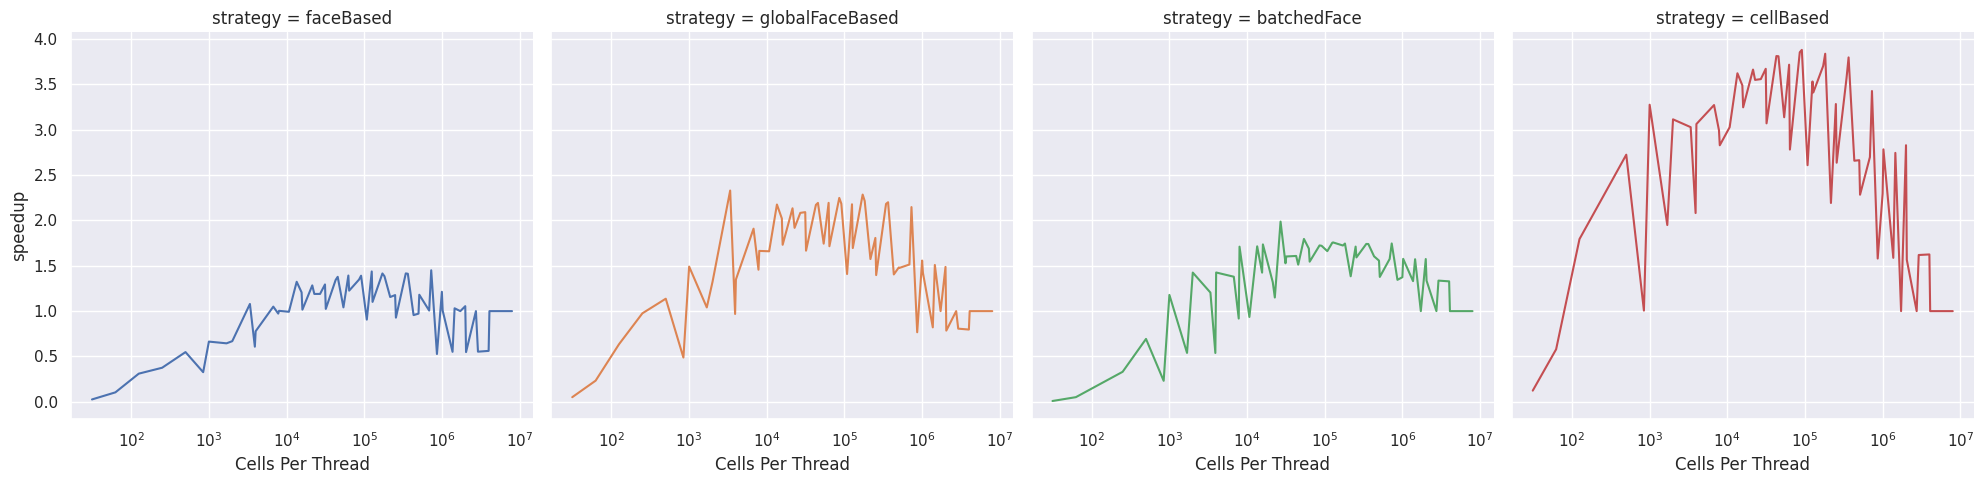

In [3]:
plot = sb.relplot(data=df, x="cellsPerCpu", y="speedup", hue="strategy", kind="line", err_style=None, col="strategy", legend=False)
plot.set(
    xlabel="Cells Per Thread"
)
plot.set(xscale="log")
plt.tight_layout()

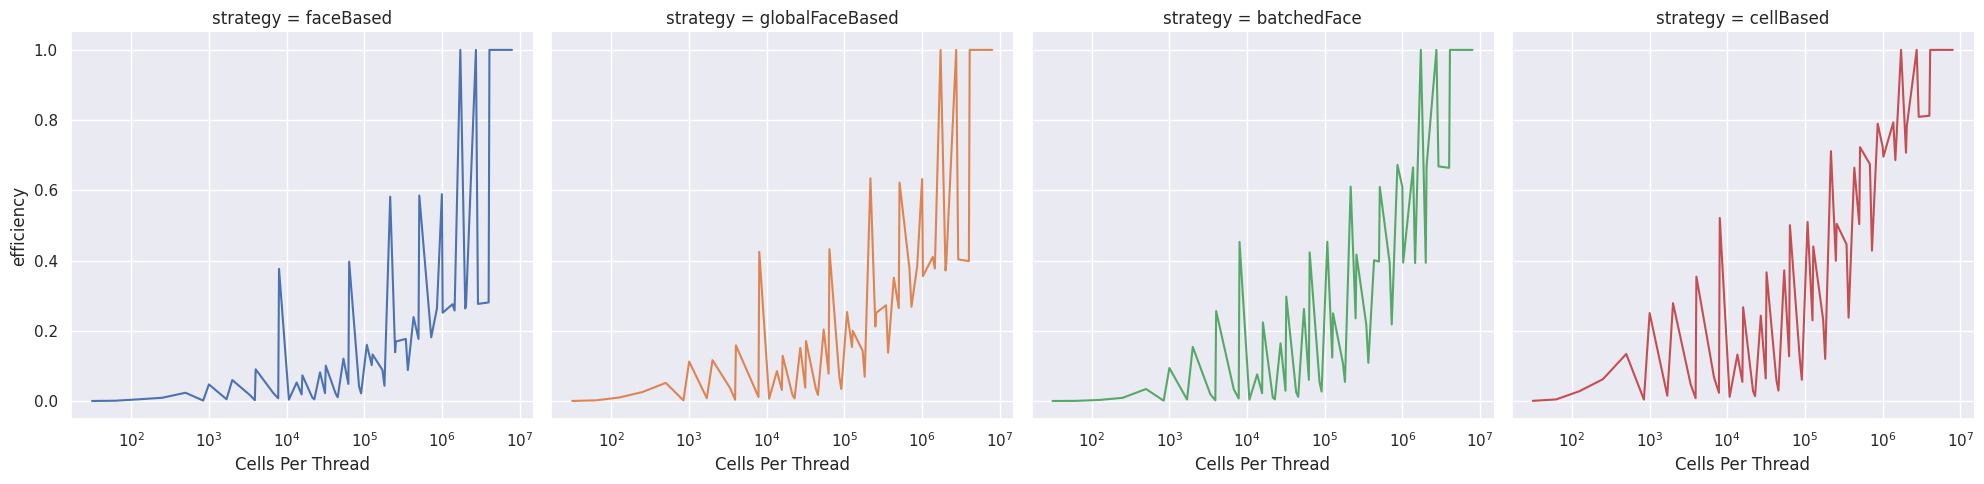

In [4]:
plot = sb.relplot(data=df, x="cellsPerCpu", y="efficiency", hue="strategy", kind="line", err_style=None, col="strategy", legend=False)
plot.set(
    xlabel="Cells Per Thread"
)
plot.set(xscale="log")
plt.tight_layout()

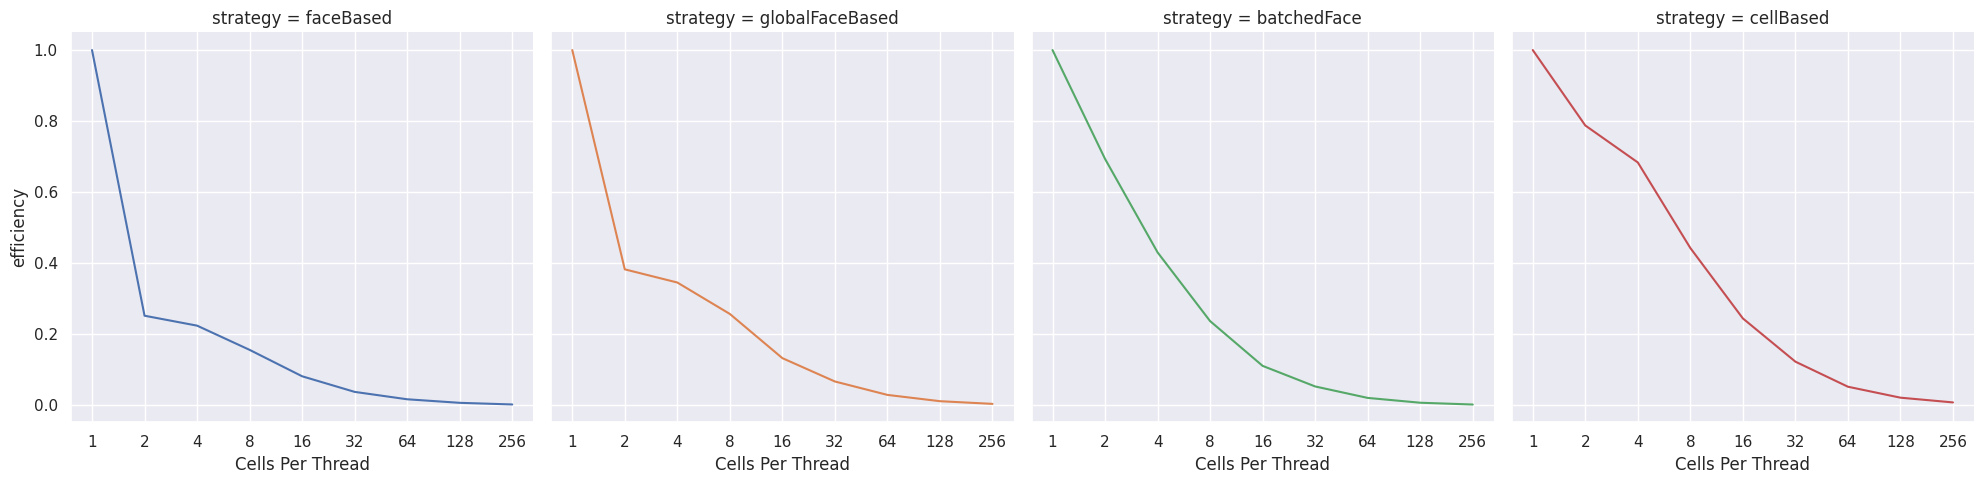

In [5]:
plot = sb.relplot(data=df, x="Threads", y="efficiency", hue="strategy", kind="line", err_style=None, col="strategy", legend=False)
plot.set(
    xlabel="Cells Per Thread"
)
plot.set(xscale="log")
for ax in plot.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(df["Threads"].unique())

    ax.set_xticklabels(labels=df["Threads"].unique())

plt.tight_layout()

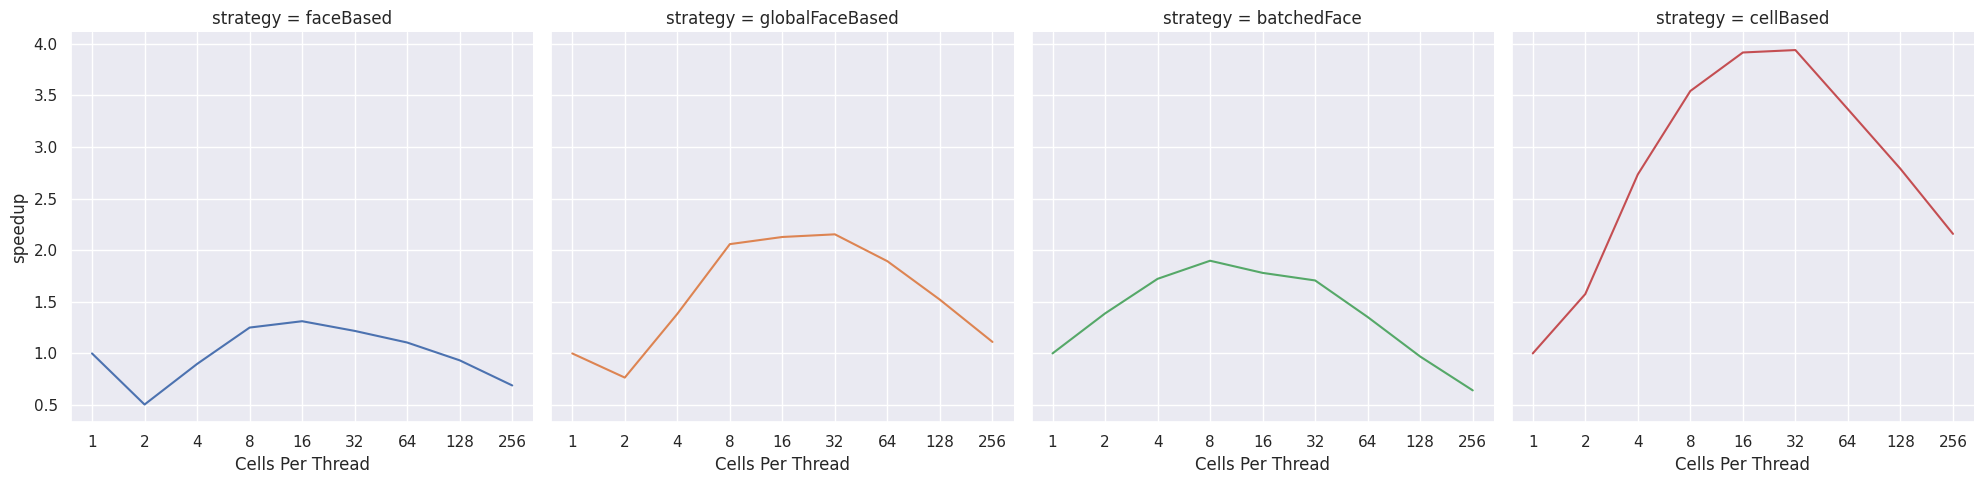

In [6]:
plot = sb.relplot(data=df, x="Threads", y="speedup", hue="strategy", kind="line", err_style=None, col="strategy", legend=False)
plot.set(
    xlabel="Cells Per Thread"
)
plot.set(xscale="log")

for ax in plot.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(df["Threads"].unique())

    ax.set_xticklabels(labels=df["Threads"].unique())

plt.tight_layout()

In [7]:
plot = sb.relplot(data=df[df["case_long"] == "cases/Lid-Driven-Cavities/240/"], x="Threads", y="speedup", hue="strategy", kind="line", err_style=None, col="strategy", legend=False)
plot.set(
    xlabel="Cells Per Thread"
)
plot.set(xscale="log")

for ax in plot.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(df["Threads"].unique())

    ax.set_xticklabels(labels=df["Threads"].unique())

plt.tight_layout()

KeyError: 'strategy'

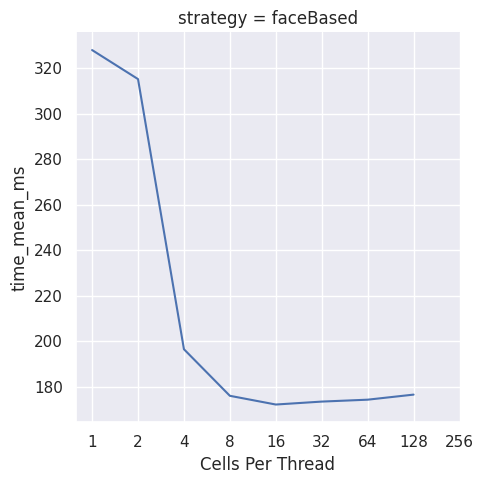

In [136]:
plot = sb.relplot(data=df[df["case_long"] == "cases/Lid-Driven-Cavities/240/"], x="Threads", y="time_mean_ms", hue="strategy", kind="line", err_style=None, col="strategy", legend=False)
plot.set(
    xlabel="Cells Per Thread"
)
plot.set(xscale="log")

for ax in plot.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(df["Threads"].unique())

    ax.set_xticklabels(labels=df["Threads"].unique())

plt.tight_layout()

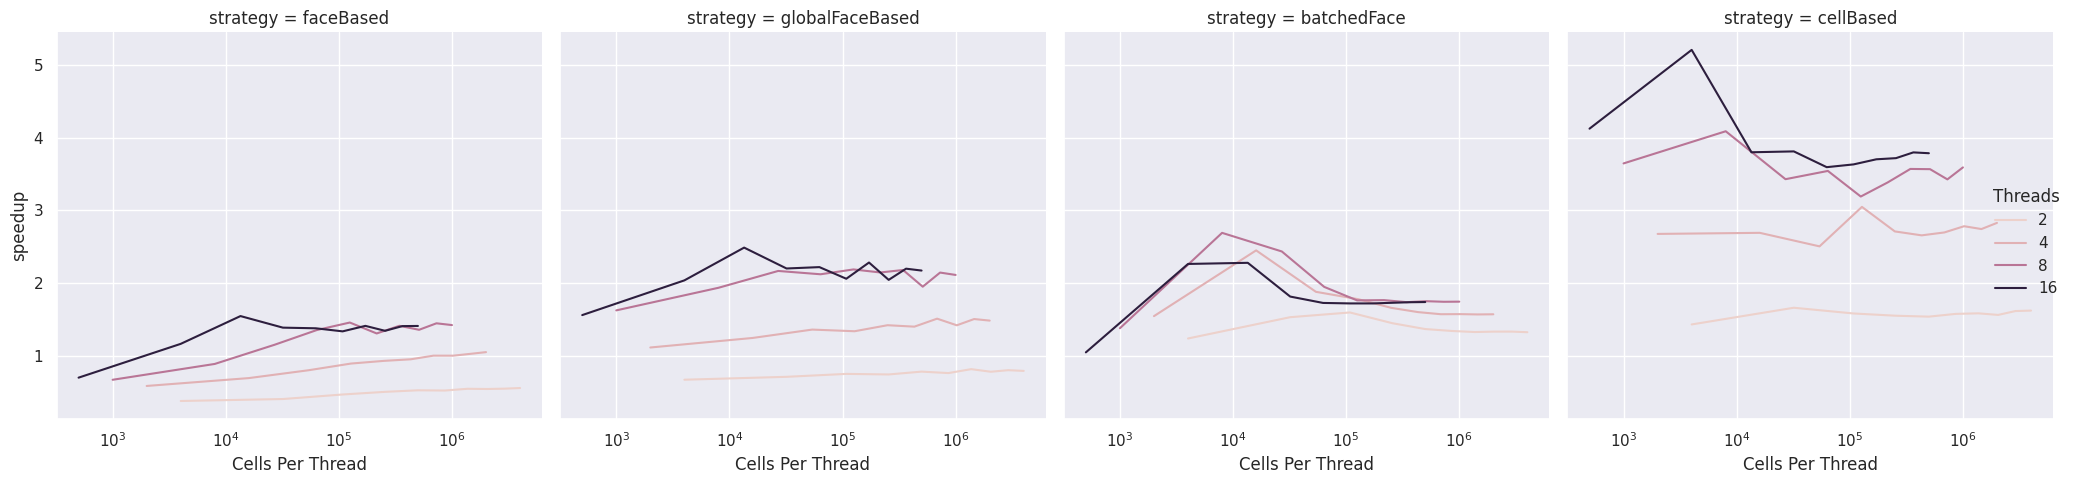

In [8]:
plot = sb.relplot(data=df[(df["Threads"] <= 16) & (df["Threads"] > 1)], x="cellsPerCpu", y="speedup", hue="Threads", kind="line", err_style=None, col="strategy", facet_kws={'sharey': True, 'sharex': True})
plot.set(
    xlabel="Cells Per Thread"
)
plot.set(xscale="log")

# for ax in plot.axes.flat:
#     labels = ax.get_xticklabels() # get x labels
#     ax.set_xticks(df["Threads"].unique())

#     ax.set_xticklabels(labels=df["Threads"].unique())

plt.tight_layout()

In [20]:
df[df["strategy"] == "faceBased"]["efficiency"]

0      1.000000
4      0.265243
8      0.233617
12     0.182603
16     0.086363
         ...   
340    0.086921
344    0.040488
348    0.017465
352    0.006114
356    0.001797
Name: efficiency, Length: 90, dtype: float64

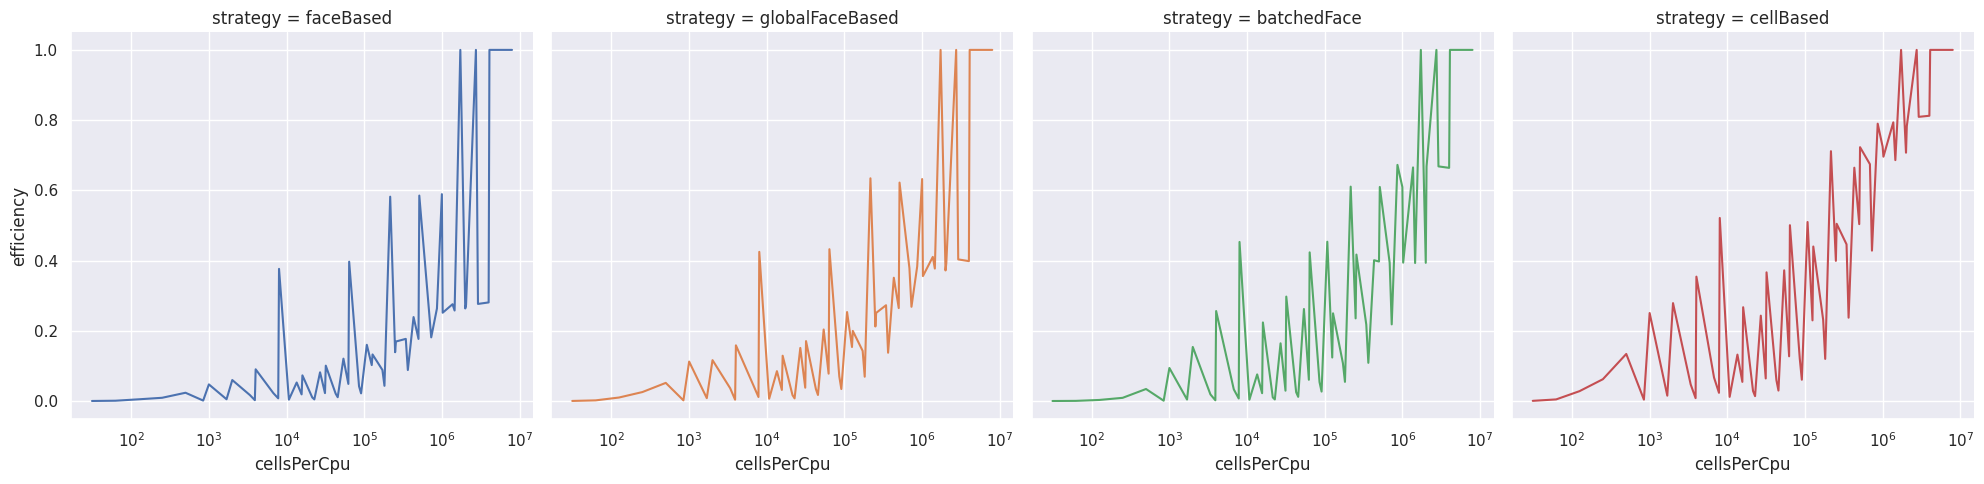

In [9]:
yvar = "speedup"

plot = sb.relplot(data=df, x="cellsPerCpu", y="efficiency", hue="strategy", kind="line", col="strategy", legend=False, err_style=None,)
axes = plot.axes.flat
T = df["Threads"].unique()
# plot.set(xlabel="Threads")
# for ax in axes:
#     ax.set_xticks(list(range(1,9)))
#     ax.set_xticklabels(labels=T)
#     ax.plot([1,7], [1,7], color='r',linestyle="dashed")
#     ax.set_yticks(list(range(1,9)))
#     ax.set_yticklabels(labels=T)
# for col_val, ax in plot.axes_dict.items():
#     ax1 = ax.twinx()
#     ax1.grid(False)
#     sb.lineplot(data=df[df['strategy'] == col_val], x="logthp1", y="efficiency", ax=ax1, color="gray",)
#     ax1.set_ylabel('')
#     # subset data for this facet
#     sub = df[
#         (df["strategy"] == col_val)
#     ]

    # if not sub.empty:
    #     # find row with max y
    #     # idx = sub[sub["Threads"] != 1]["efficiency"].idxmax()
    #     # max_row = sub.loc[idx]
    #     # print(f"drawing for {row_val},{col_val} at {max_row["logthp1"]},{max_row[yvar]}")
    #     # annotate
    #     ax.text(
    #         max_row["logthp1"],
    #         max_row[yvar],
    #         f"{round(max_row[yvar], 3)}",
    #         color="black",
    #         fontsize=9,
    #         ha="left",
    #         va="bottom"
    #     )
    #     ax.scatter(
    #         max_row["logthp1"],
    #         max_row[yvar],
    #         color="red",
    #         s=50,
    #         zorder=5
    #     )
plt.xscale("log")
plt.tight_layout()

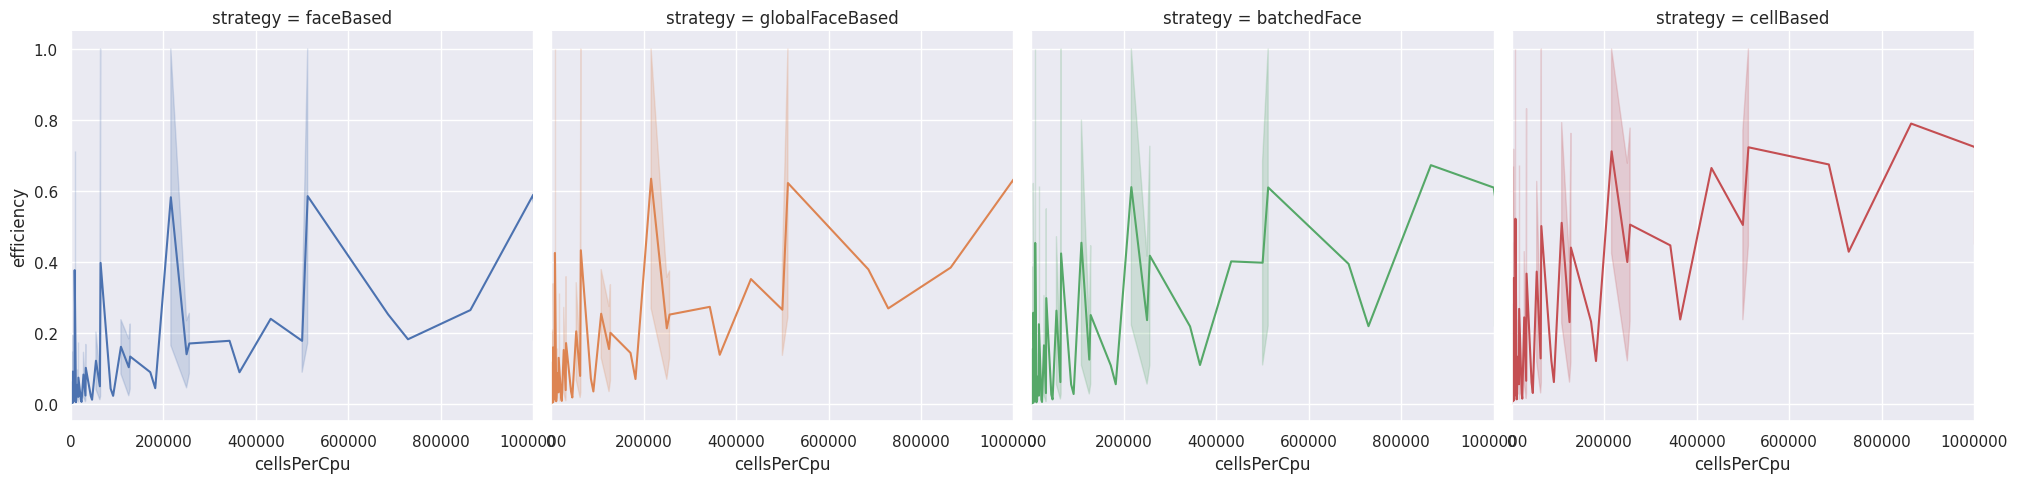

In [15]:
plot = sb.relplot(data=df, x="cellsPerCpu", y="efficiency", hue="strategy", kind="line", col="strategy", legend=False)
axes = plot.axes.flat
T = df["Threads"].unique()
# plot.set(xscale="log")
plt.xlim([0, 1000000])
for ax in axes:
    labels = ax.get_xticklabels() # get x labels
plt.gca().ticklabel_format(axis='x', style='plain')


In [21]:
bins = [0, 50000, 100000, 300000, 500000, max(df["cellsPerCpu"])]
labels = ['0-50k', '50k-100k', '100k-300k', '300k-500k', '500k+']

df['CPTranges'] = pd.cut(df['cellsPerCpu'], bins=bins, labels=labels)

ValueError: The number of FixedLocator locations (8), usually from a call to set_ticks, does not match the number of labels (9).

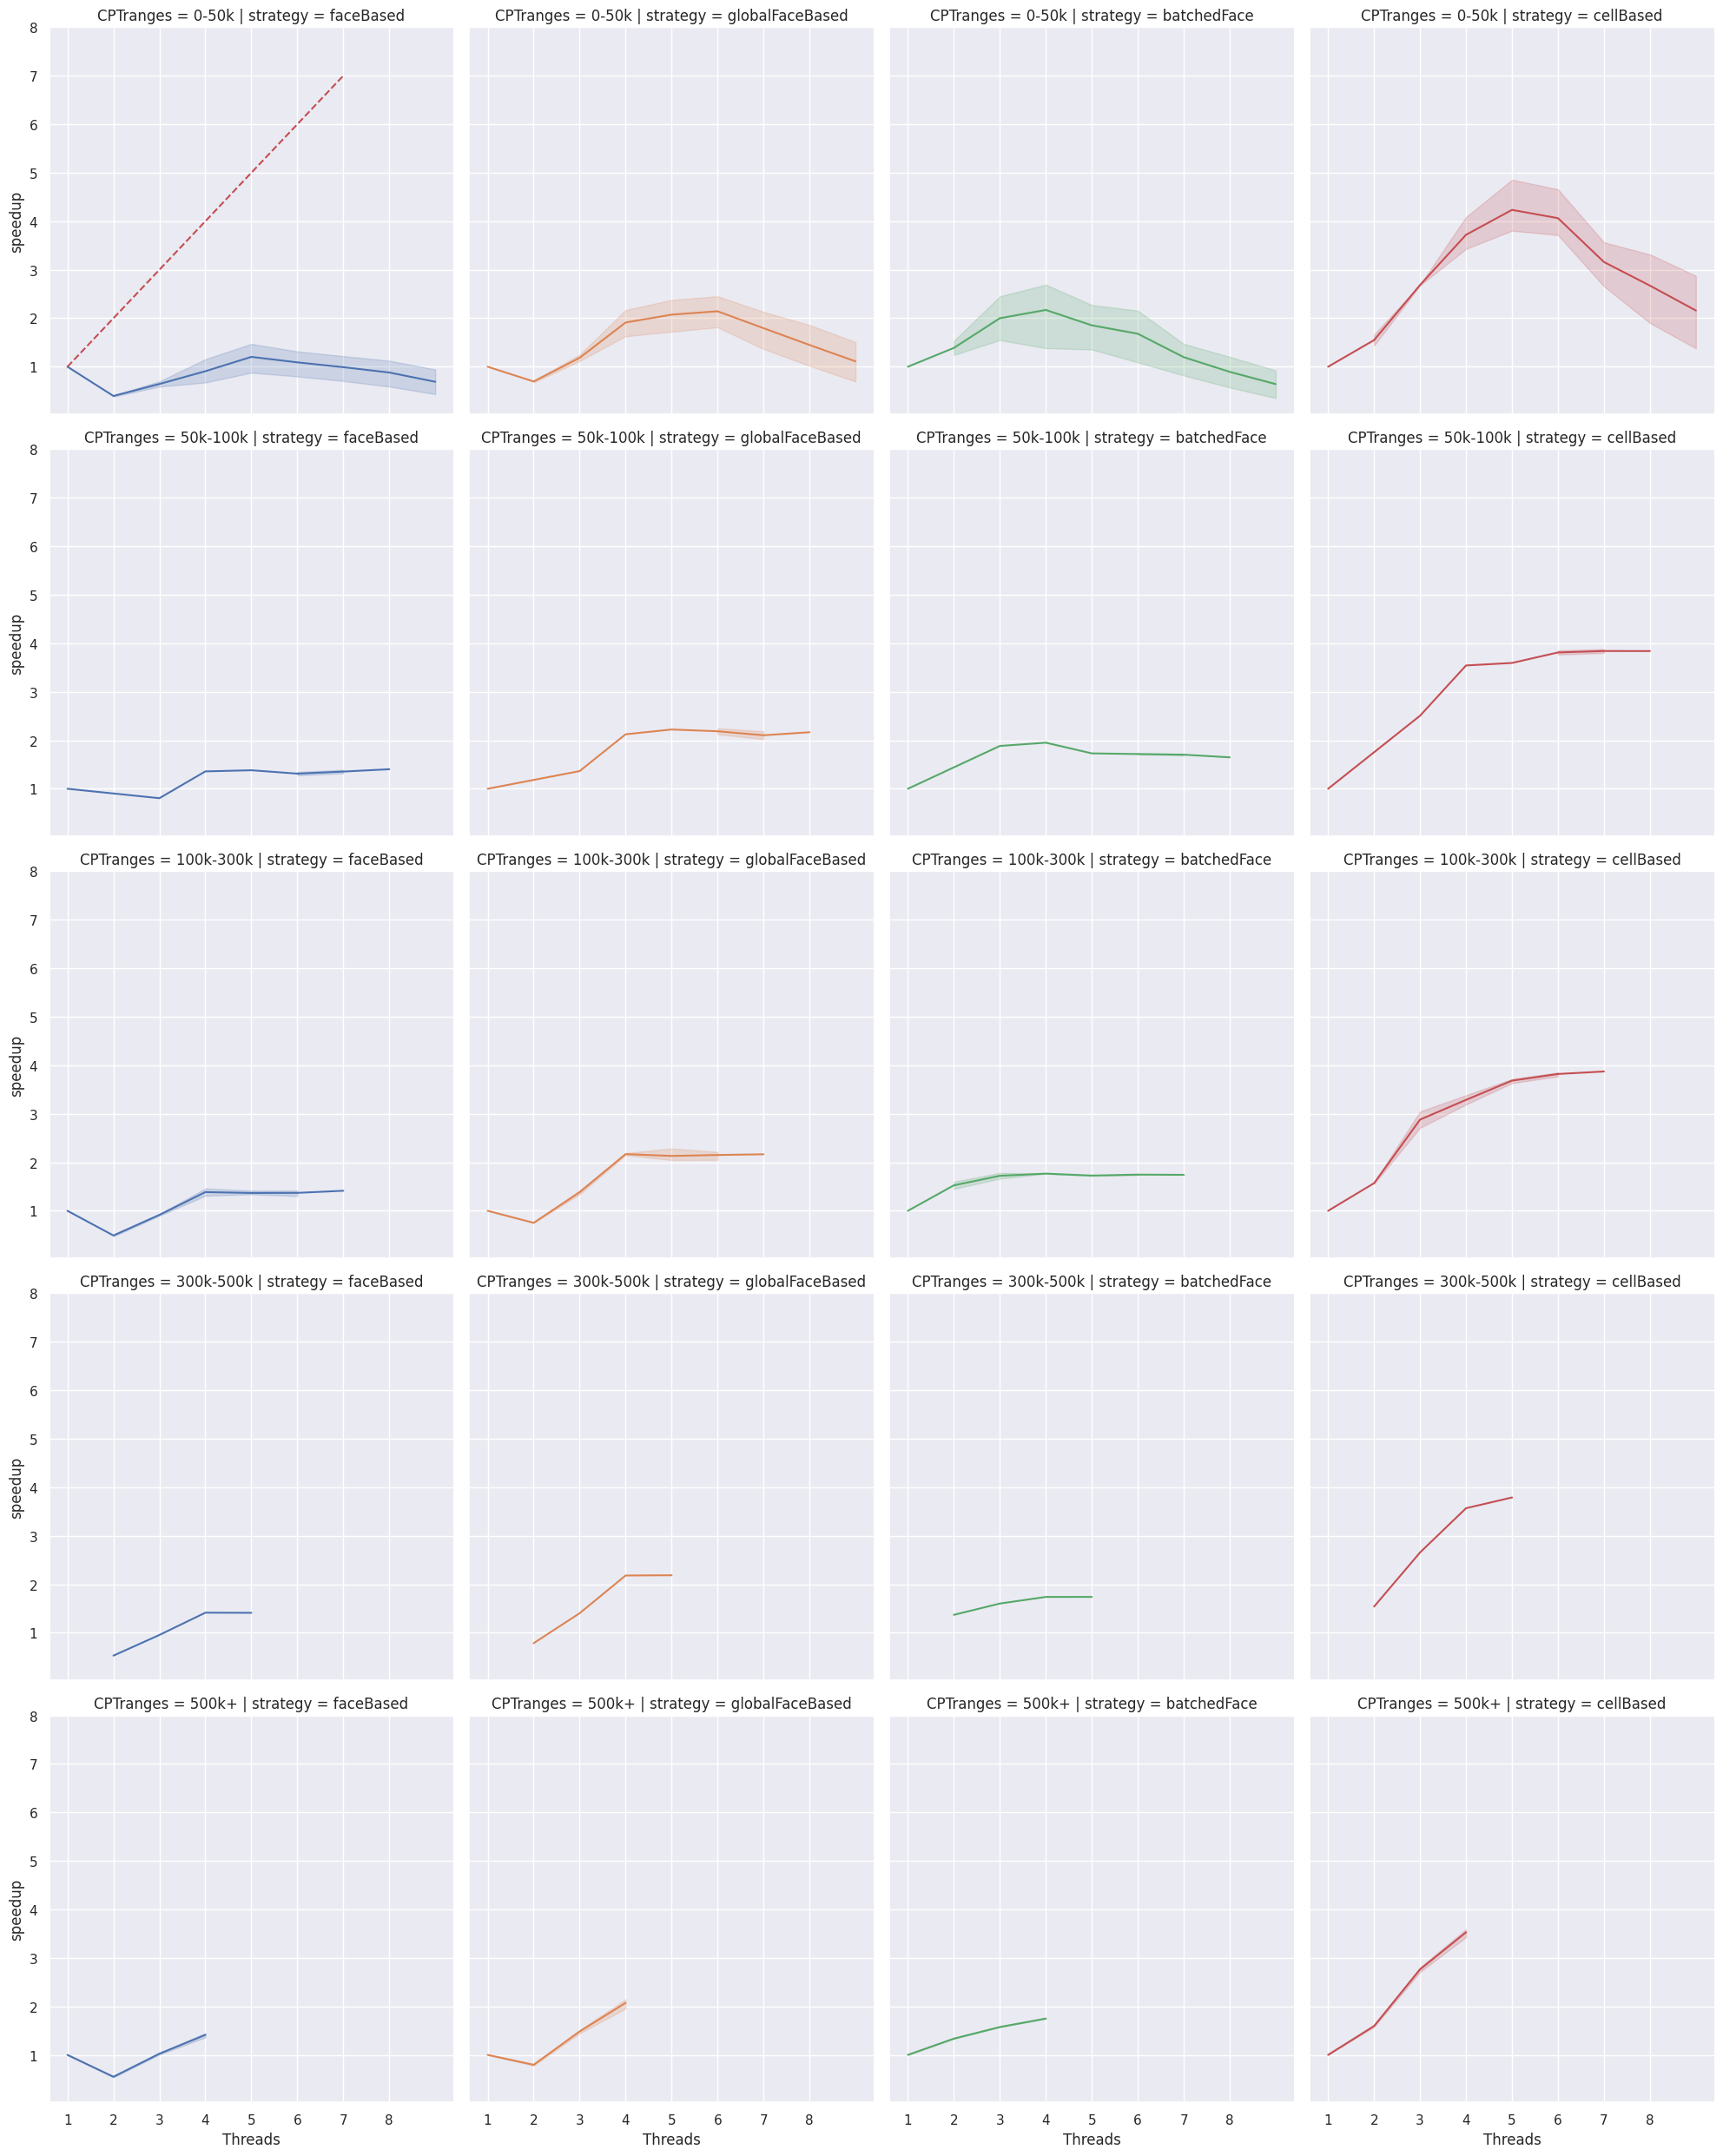

In [22]:
yvar = "speedup"
plot = sb.relplot(data=df, x="logthp1", y=yvar, hue="strategy", kind="line", col="strategy", row="CPTranges", legend=False)
axes = plot.axes.flat
T = df["Threads"].unique()
plot.set(xlabel="Threads")
for ax in axes:
    ax.set_xticks(list(range(1,9)))
    # ax.set_xticklabels(labels=T)
    ax.plot([1,7], [1,7], color='r',linestyle="dashed")
    ax.set_yticks(list(range(1,9)))
    ax.set_yticklabels(labels=T)
max_df = df.loc[df.groupby(['CPTranges', 'strategy'])['speedup'].idxmax()]
print(f"{len(max_df)} == {len(axes)}")
plt.xlim([0, 10])
# Loop through each facet
for (row_val, col_val), ax in plot.axes_dict.items():
    # subset data for this facet
    sub = df[
        (df["CPTranges"] == row_val) &
        (df["strategy"] == col_val)
    ]

    if not sub.empty:
        # find row with max y
        idx = sub[sub["Threads"] != 1]["efficiency"].idxmax()
        max_row = sub.loc[idx]
        print(f"drawing for {row_val},{col_val} at {max_row["logthp1"]},{max_row[yvar]}")
        # annotate
        ax.text(
            max_row["logthp1"],
            max_row[yvar],
            f"{round(max_row[yvar], 3)}",
            color="black",
            fontsize=9,
            ha="left",
            va="bottom"
        )
        ax.scatter(
            max_row["logthp1"],
            max_row[yvar],
            color="red",
            s=50,
            zorder=5
        )

In [ ]:
print(df["logth"].unique())
print(df["Threads"].unique())

In [ ]:
df

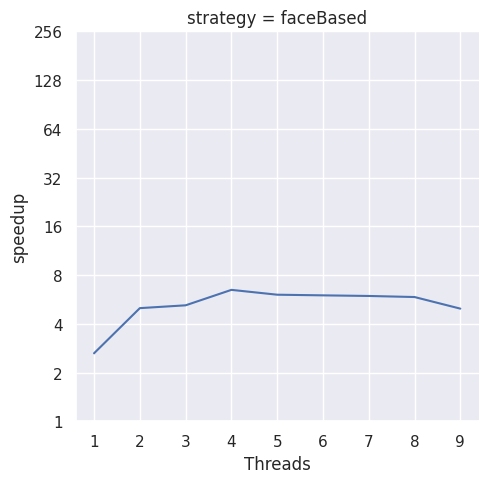

In [155]:
yvar = "speedup"
plot = sb.relplot(data=df[df["variant"].str.contains("SOAFusedFaceBased")], x="logthp1", y=yvar, hue="strategy", kind="line", col="strategy", legend=False)
T = df["Threads"].unique()
axes = plot.axes.flat
plot.set(xlabel="Threads")
for ax in axes:
    ax.set_xticks(list(range(1,10)))
    # ax.set_xticklabels(labels=T)
    # ax.plot([1,10], [1,10], color='r',linestyle="dashed")
    ax.set_yticks(list(range(1,10)))
    ax.set_yticklabels(labels=T)


20 == 1


(0.0, 10.0)

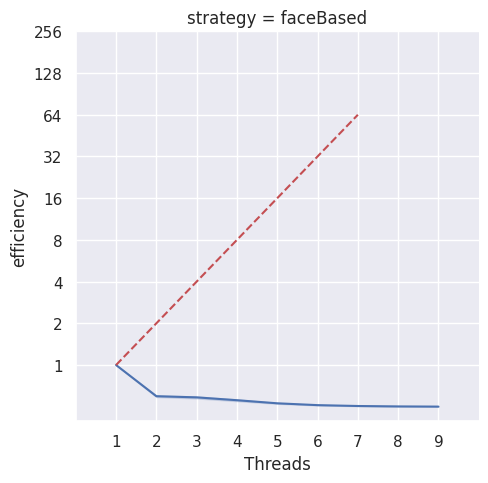

In [23]:
yvar = "efficiency"
plot = sb.relplot(data=df[df["variant"].str.contains("SOAFusedFaceBased")], x="logthp1", y=yvar, hue="strategy", kind="line", col="strategy", legend=False)
axes = plot.axes.flat
T = df["Threads"].unique()
plot.set(xlabel="Threads")
for ax in axes:
    ax.set_xticks(list(range(1,10)))
    # ax.set_xticklabels(labels=T)
    ax.plot([1,7], [1,7], color='r',linestyle="dashed")
    ax.set_yticks(list(range(1,10)))
    ax.set_yticklabels(labels=T)
max_df = df.loc[df.groupby(['CPTranges', 'strategy'])['speedup'].idxmax()]
print(f"{len(max_df)} == {len(axes)}")
plt.xlim([0, 10])
# Loop through each facet
# for (row_val, col_val), ax in plot.axes_dict.items():
#     # subset data for this facet
#     sub = df[
#         (df["CPTranges"] == row_val) &
#         (df["strategy"] == col_val)
#     ]

#     if not sub.empty:
#         # find row with max y
#         idx = sub[sub["Threads"] != 1]["efficiency"].idxmax()
#         max_row = sub.loc[idx]
#         print(f"drawing for {row_val},{col_val} at {max_row["logthp1"]},{max_row[yvar]}")
#         # annotate
#         ax.text(
#             max_row["logthp1"],
#             max_row[yvar],
#             f"{round(max_row[yvar], 3)}",
#             color="black",
#             fontsize=9,
#             ha="left",
#             va="bottom"
#         )
#         ax.scatter(
#             max_row["logthp1"],
#             max_row[yvar],
#             color="red",
#             s=50,
#             zorder=5
#         )

In [27]:
df["Threads"]

0        1
1        1
2        1
3        1
4        2
      ... 
355    128
356    256
357    256
358    256
359    256
Name: Threads, Length: 360, dtype: int64

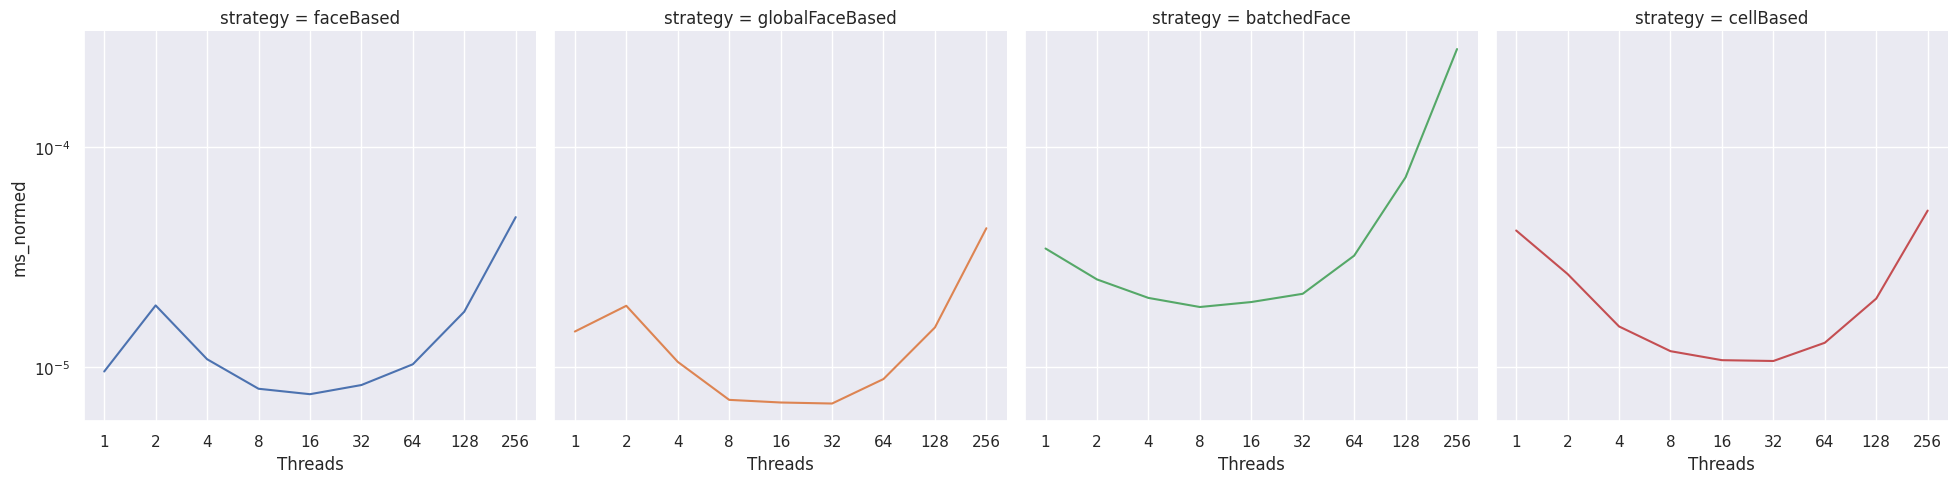

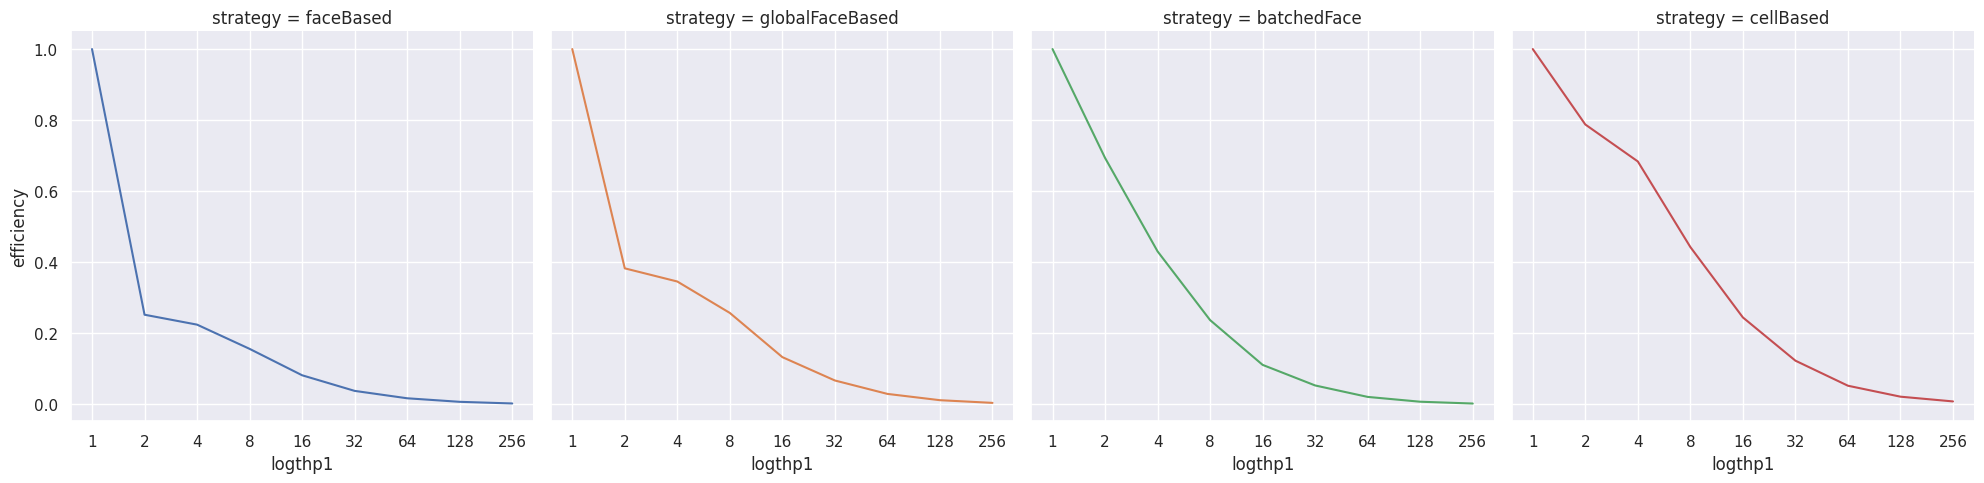

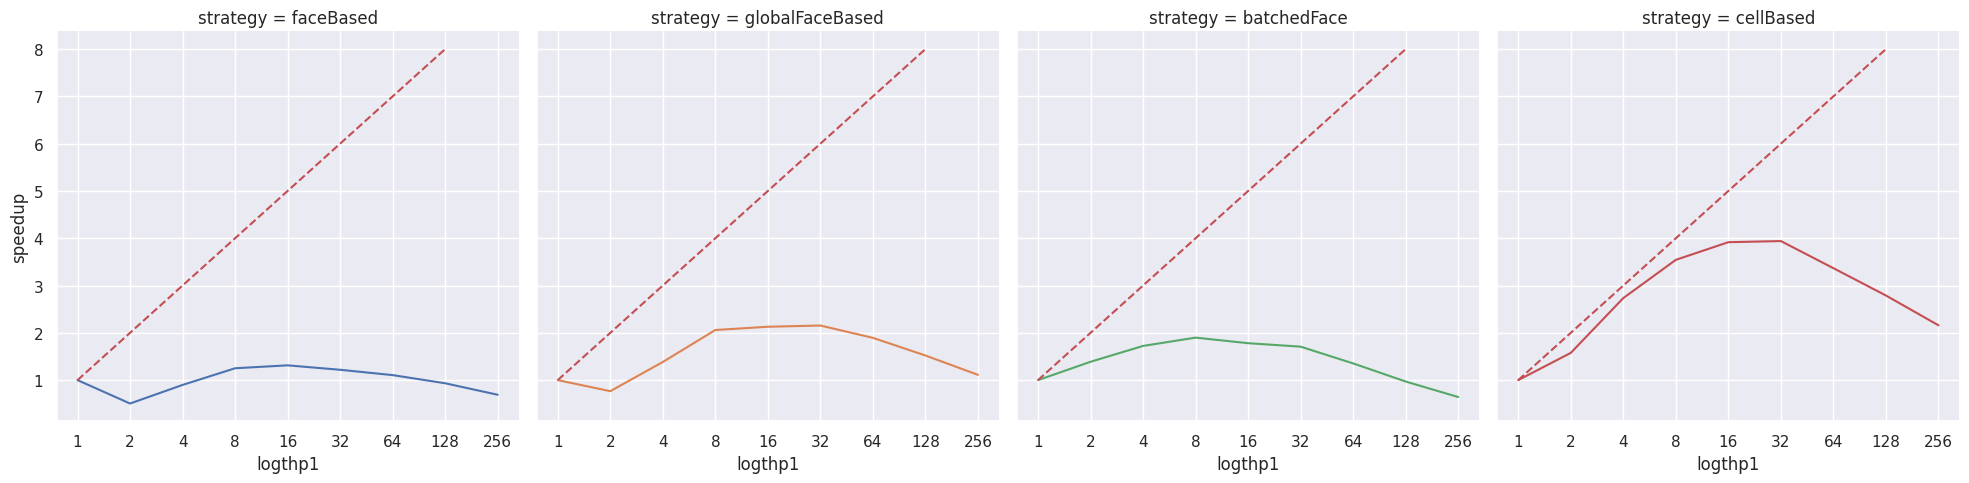

In [59]:
yvar = "ms_normed"
plot = sb.relplot(data=df[df["Threads"] != 0], x="logthp1", y=yvar, hue="strategy", kind="line", err_style=None,col="strategy", legend=False)
axes = plot.axes.flat
T = df["Threads"].unique()
plot.set(xlabel="Threads")
plt.yscale("log")
for ax in axes:
    ax.set_xticks(list(range(1,10)))
    ax.set_xticklabels(labels=T)
    # ax.plot([2,8], [2,8], color='r',linestyle="dashed")
    # ax.set_yticks(list(range(1,10)))
    # ax.set_yticklabels(labels=T)
max_df = df.loc[df.groupby(['CPTranges', 'strategy'])['speedup'].idxmax()]

plot2 = sb.relplot(data=df[df["Threads"] != 0], x="logthp1", y="efficiency", hue="strategy", kind="line", err_style=None,col="strategy", legend=False)
for ax in plot2.axes.flat:
    ax.set_xticks(list(range(1,10)))
    ax.set_xticklabels(labels=T)
plot3 = sb.relplot(data=df[df["Threads"] != 0], x="logthp1", y="speedup", hue="strategy", kind="line", err_style=None,col="strategy", legend=False)

for ax in plot3.axes.flat:
    ax.set_xticks(list(range(1,10)))
    ax.set_xticklabels(labels=T)
    ax.plot([1,8], [1,8], color='r',linestyle="dashed")
    # ax.set_yticks(list(range(1,10)))
    # ax.set_yticklabels(labels=T)

In [3]:
cpu["case_num"] = cpu["case_long"].str.extract(r'(\d+)/?$').astype(int)

# build sorted order
order = (
    cpu[["case_long", "case_num"]]
    .drop_duplicates()
    .sort_values("case_num")
    ["case_long"]
)

In [11]:
cpu["strategy"].unique()


<StringArray>
['faceBased', 'globalFaceBased', 'batchedFace', 'cellBased']
Length: 4, dtype: str

In [49]:
ncells = sorted((round(cpu["cells"]**(1/3))).unique().astype(int))
strats  =['faceBased', 'globalFaceBased', 'batchedFace', 'cellBased']

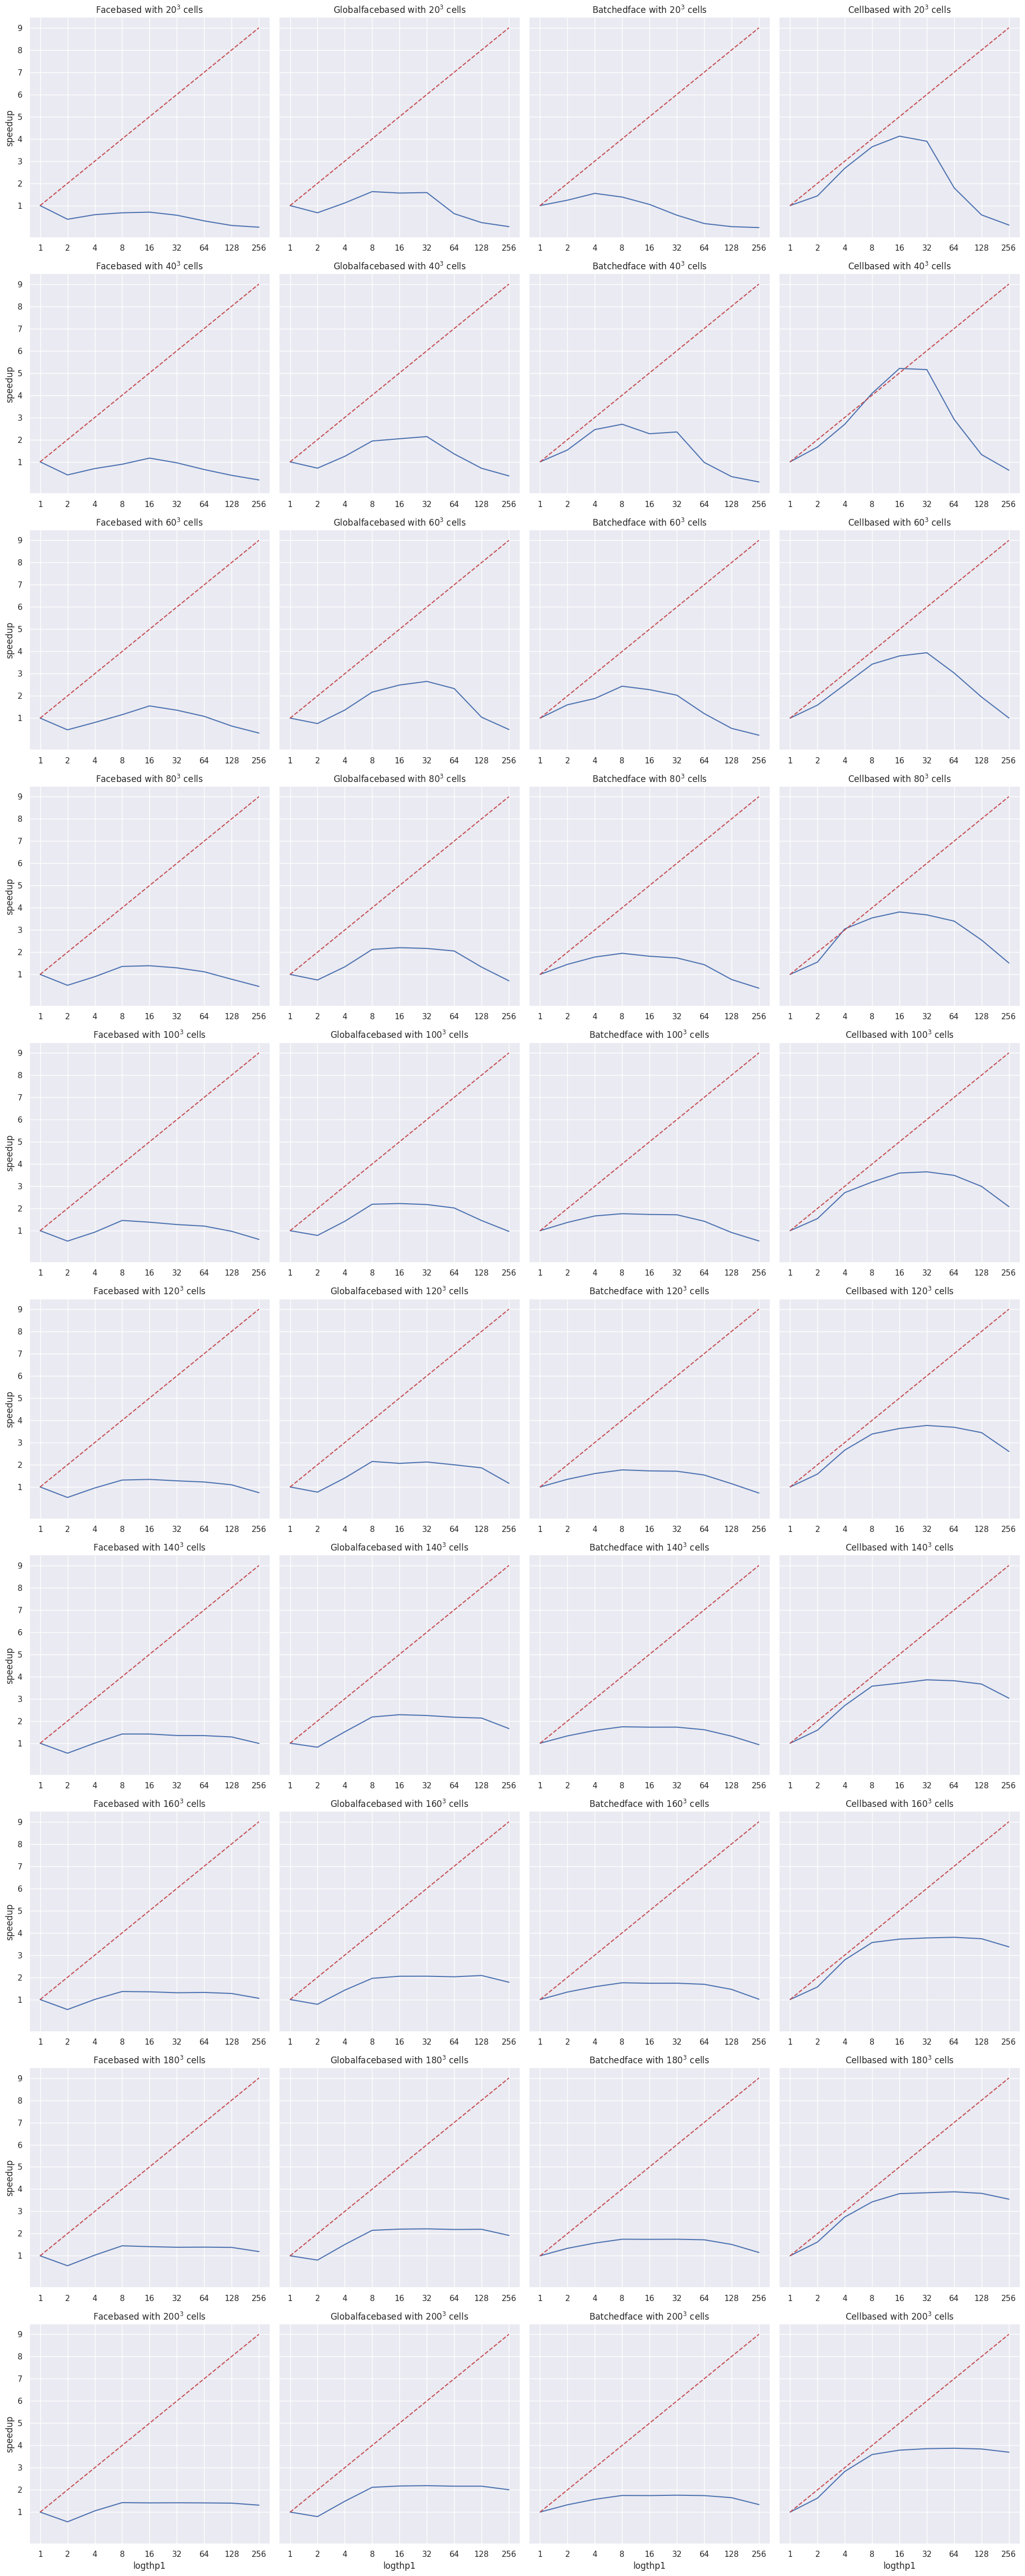

In [54]:
plot = sb.relplot(data=cpu, x="logthp1", y="speedup", kind="line", col="strategy", row="case_long", row_order=order, col_order=strats)
axes = plot.axes
for i in range(len(order)):
    for j in range(4):
        ax = axes[i,j]
        ax.set_title(f"{strats[j].capitalize()} with ${ncells[i]}^3$ cells")
        ax.tick_params(labelbottom=True)
        ax.set_xticks(list(range(1,10)))
        ax.set_xticklabels(labels=cpu["Threads"].unique())
        ax.plot([1,9], [1,9], color='r',linestyle="dashed")
        ax.set_yticks(list(range(1,10)))
        # ax.set_yticklabels(labels=T)
plt.tight_layout()

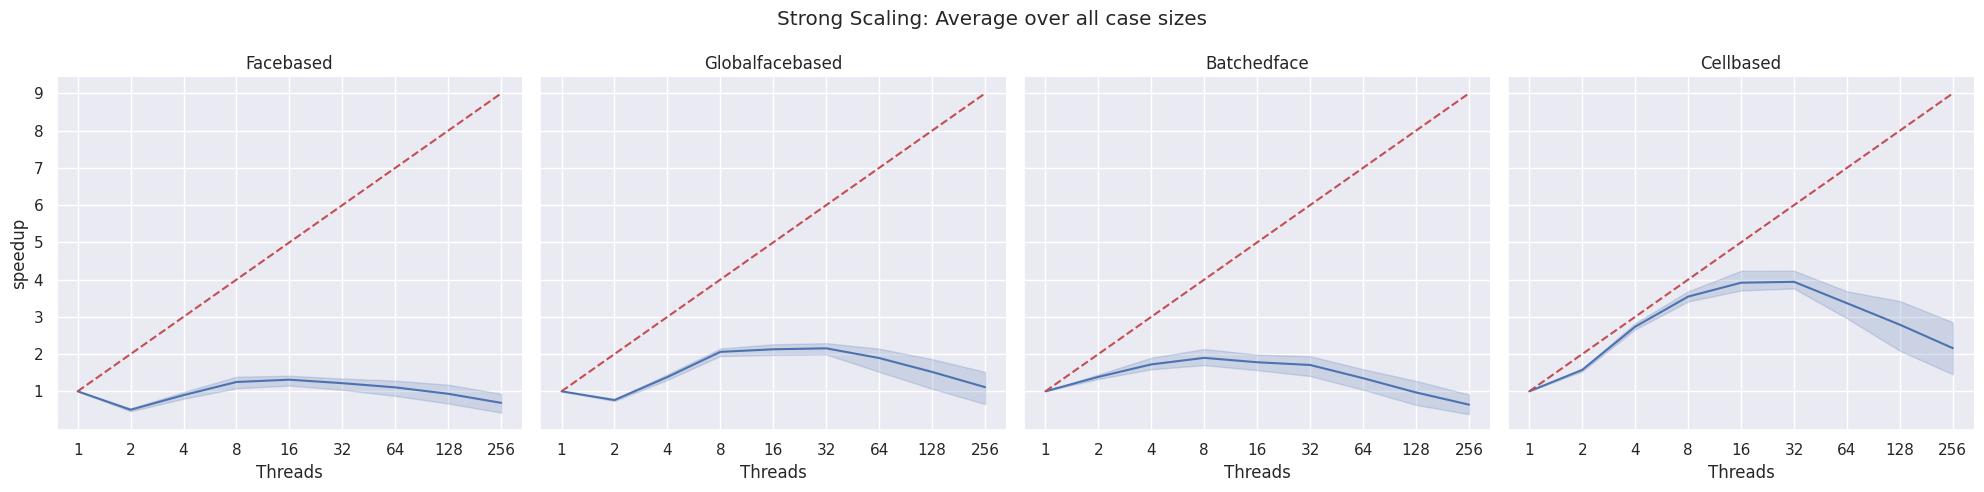

In [ ]:
plot = sb.relplot(data=cpu, x="logthp1", y="speedup", kind="line", col="strategy",  col_order=strats)
axes = plot.axes.flat

for i, ax in enumerate(axes):
    ax.set_title(f"{strats[i].capitalize()}")
    ax.tick_params(labelbottom=True)
    ax.set_xticks(list(range(1,10)))
    ax.set_xticklabels(labels=cpu["Threads"].unique())
    ax.set_xlabel("Threads")
    ax.plot([1,9], [1,9], color='r',linestyle="dashed")
    ax.set_yticks(list(range(1,10)))
    # ax.set_yticklabels(labels=T)
plt.suptitle("Strong Scaling: Average over all case sizes")
plt.tight_layout()

In [74]:
gpu = pd.read_csv("test2.csv", skip_blank_lines=True)
gpu["cells"] = [int(x.rsplit("/", 2)[1])**3 for x in gpu["case_long"]]
gpu["ms_normed"] = df["time_mean_ms"] / df["cells"]

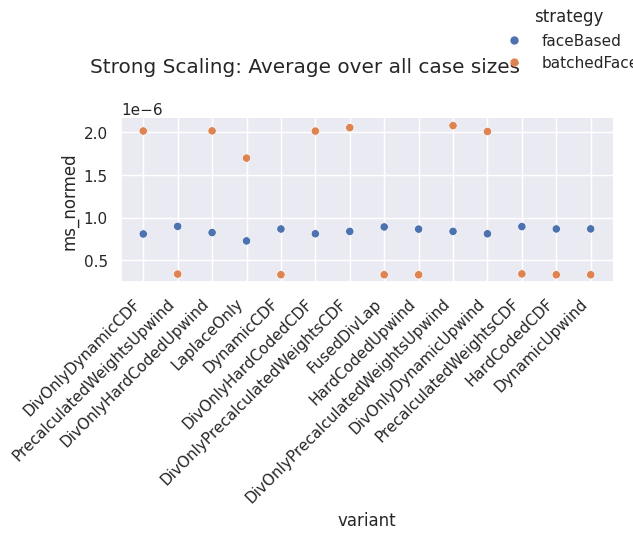

In [101]:
plot = sb.relplot(data=gpu, x="variant", y="ms_normed", hue="strategy")
axes = plot.axes.flat

for i, ax in enumerate(axes):
    plot.set_xticklabels(ax.get_xticklabels(), 
                        rotation=45, 
                        horizontalalignment='right'
    )

leg = plot._legend
leg.set_bbox_to_anchor([1,1])  # coordinates of lower left of bounding box
leg._loc
#     ax.set_title(f"{strats[i].capitalize()}")
#     ax.tick_params(labelbottom=True)
#     ax.set_xticks(list(range(1,10)))
#     ax.set_xticklabels(labels=cpu["Threads"].unique())
#     ax.set_xlabel("Threads")
#     ax.plot([1,9], [1,9], color='r',linestyle="dashed")
#     ax.set_yticks(list(range(1,10)))
    # ax.set_yticklabels(labels=T)

plt.suptitle("Strong Scaling: Average over all case sizes")
plt.tight_layout()